# **Step 1:** Importing Libraries and Connecting to Google Drive

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from google.colab import drive
import pandas as pd

In [23]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Step 2:** Reading Images and the Annotations File

In [24]:
# Annotations for previous training:

data_path = '/content/drive/MyDrive/FinalProject/Images1'
# For running in Tamir's env: '/content/drive/MyDrive/Colab Notebooks/Intro ML & DL/suvelocity/Project Semi Supervised'
# For running in Nitzan's env:'/content/drive/MyDrive/FinalProject/Images1'
# Load the annotations file (x, y, angle)
annotations = np.load(os.path.join(data_path, 'agent_0_annotations.npy'))

# === ORIGINAL NORMALIZATION VALUES ===
max_x = 360.0 # Divided by the image width
max_y = 360.0 # Divided by the image height
max_angle = 360.0

# Normalize all annotations to [0, 1]
annotations = annotations / np.array([max_x, max_y, max_angle])

# Collect image file names
image_files = [f for f in os.listdir(data_path) if f.lower().endswith('.jpg')]

# Optional: Print image size to confirm (using first image)
img_sample = Image.open(os.path.join(data_path, image_files[0]))
print("Sample image size:", img_sample.size)  # (width, height)

Sample image size: (360, 360)


# **Step 3:** Custom Dataset Class (Regression + Autoencoder)

In [25]:
# Regression - Define a custom dataset class by inheriting from PyTorch's Dataset base class
class CustomImageDataset(Dataset):
    def __init__(self, image_dir, image_files, annotations, transform=None): # Initialize the dataset with image directory, file list, annotations, and optional transforms
        self.image_dir = image_dir
        self.image_files = image_files
        self.annotations = annotations
        self.transform = transform

    def __len__(self): # Define how many items the dataset contains
        return len(self.image_files)

    def __getitem__(self, idx): # Get a single image and its corresponding annotation by index
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path) #.convert("RGB") # Ensure image is in RGB format

        if self.transform:
            image = self.transform(image)

        # For Regression, the target is the numeric label (x, y, angle)
        label = torch.tensor(self.annotations[idx], dtype=torch.float32)
        return image, label



# Autoencoder - Define a custom dataset class by inheriting from PyTorch's Dataset base class
class ImageDataset4Autoencoder(Dataset):
    def __init__(self, image_dir, image_files, annotations, transform=None): # Initialize the dataset with image directory, file list, annotations, and optional transforms
        self.image_dir = image_dir
        self.image_files = image_files
        self.annotations = annotations
        self.transform = transform

    def __len__(self): # Define how many items the dataset contains
        return len(self.image_files)

    def __getitem__(self, idx): # Get a single image and its corresponding annotation by index
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path) #.convert("RGB") # Ensure image is in RGB format

        if self.transform:
            image = self.transform(image)

        # For Autoencoder, the target is the image itself
        return image, image

# **Step 4:** Image Transformation and Augmentation

In [26]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# **Step 5 (Autoencoder - unlabeled):** Splitting into Train\Test and Preparing the DataLoader

In [27]:
# Split the image filenames and annotations into training and testing sets (80% train, 20% test)
train_files, test_files, train_annots, test_annots = train_test_split(
    image_files, annotations, test_size=0.2, random_state=42
)
# random_state sets a fixed seed for random number generation, ensuring that the data split is the same every time you run the code
# Without random_split the split will change every time — making it impossible to reproduce or consistently compare results

train_dataset = ImageDataset4Autoencoder(data_path, train_files, train_annots, transform=transform)
test_dataset = ImageDataset4Autoencoder(data_path, test_files, test_annots, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# **Step 6.1 (Autoencoder):** Define the Autoencoder model class

In [28]:
class Autoencoder(nn.Module):
    def __init__(self, autoencoder=True):
        super().__init__()
        self.autoencoder = autoencoder

        # Encoder = ResNet18 (non-pretrained)
        base = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-2])  # (B, 512, 7, 7)

        # Decoder: 512x7x7 to 3x224x224
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), #256x1
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), #180x1
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), #64x1
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), #32x1
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1), #3x1
            nn.Sigmoid()  # Output shape: (B, 3, 224, 224)
        )

        # Regression head: (512×7×7) to 3
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(True),
            nn.Linear(256, 3),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.encoder(x)

        if self.autoencoder:
            # Autoencoder mode: reconstruct the input image
            return self.decoder(features)
        else:
            # Regression mode: predict (x, y, angle)
            return self.reg_head(features)


# **Step 6.2 (Autoencoder):** Checking the autoencoder model

In [29]:
# Check that the autoencoder mode is working
# Check Autoencoder net:
net_autoencoder = Autoencoder(autoencoder=True)
print(net_autoencoder.autoencoder)
# What is the shape of the input? (We want to get [32, 3, 224, 224])
sample_input, _ = next(iter(train_loader))

# What is the shape of the output? (We want to get [32, 3, 224, 224])
with torch.no_grad():
    reconstructed = net_autoencoder(sample_input)

print(sample_input.shape)
print(reconstructed.shape)

True
torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])


In [30]:
# Check Regression net:
net_regression = Autoencoder(autoencoder=False)
print(net_regression.autoencoder)
# What is the shape of the input? (We want to get [32 - batch size, 3, 224, 224])
sample_input, _ = next(iter(train_loader))

# What is the shape of the output? (We want to get ([32 - batch size, 3]))
with torch.no_grad():
    reconstructed = net_regression(sample_input)

print(sample_input.shape)
print(reconstructed.shape)

False
torch.Size([32, 3, 224, 224])
torch.Size([32, 3])


# **Step 7:** Using GPU

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
net_autoencoder = Autoencoder(autoencoder=True).to(device)

cuda


# **Step 8:** Training Autoencoder

# **Step 8.1:** Training Setup for Autoencoder

In [32]:
# Define the loss function and optimizer for the Autoencoder
criterion_autoencoder = nn.MSELoss()
optimizer_autoencoder = optim.Adam(net_autoencoder.parameters(), lr=0.001) # You can adjust the learning rate

num_epochs_autoencoder = 100 # You can adjust the number of epochs
loss_list_autoencoder = []

# **Step 8.2:** Training the Autoencoder

In [33]:
# Training loop for Autoencoder
for epoch in range(num_epochs_autoencoder):
    net_autoencoder.train()
    running_loss = 0.0
    for inputs, _ in train_loader: # Autoencoder uses the image as both input and target
        inputs = inputs.to(device)

        optimizer_autoencoder.zero_grad()
        outputs = net_autoencoder(inputs)
        loss = criterion_autoencoder(outputs, inputs) # Compare output with input
        loss.backward()
        optimizer_autoencoder.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    loss_list_autoencoder.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs_autoencoder}], Loss: {epoch_loss:.4f}")

print("Autoencoder training finished")

Epoch [1/100], Loss: 0.0444
Epoch [2/100], Loss: 0.0171
Epoch [3/100], Loss: 0.0125
Epoch [4/100], Loss: 0.0108
Epoch [5/100], Loss: 0.0102
Epoch [6/100], Loss: 0.0091
Epoch [7/100], Loss: 0.0081
Epoch [8/100], Loss: 0.0074
Epoch [9/100], Loss: 0.0047
Epoch [10/100], Loss: 0.0047
Epoch [11/100], Loss: 0.0043
Epoch [12/100], Loss: 0.0039
Epoch [13/100], Loss: 0.0046
Epoch [14/100], Loss: 0.0036
Epoch [15/100], Loss: 0.0036
Epoch [16/100], Loss: 0.0039
Epoch [17/100], Loss: 0.0035
Epoch [18/100], Loss: 0.0045
Epoch [19/100], Loss: 0.0045
Epoch [20/100], Loss: 0.0035
Epoch [21/100], Loss: 0.0031
Epoch [22/100], Loss: 0.0040
Epoch [23/100], Loss: 0.0031
Epoch [24/100], Loss: 0.0032
Epoch [25/100], Loss: 0.0027
Epoch [26/100], Loss: 0.0030
Epoch [27/100], Loss: 0.0025
Epoch [28/100], Loss: 0.0026
Epoch [29/100], Loss: 0.0026
Epoch [30/100], Loss: 0.0024
Epoch [31/100], Loss: 0.0025
Epoch [32/100], Loss: 0.0026
Epoch [33/100], Loss: 0.0024
Epoch [34/100], Loss: 0.0023
Epoch [35/100], Loss: 0

# **Step 8.3:** Graph for the Autoencoder

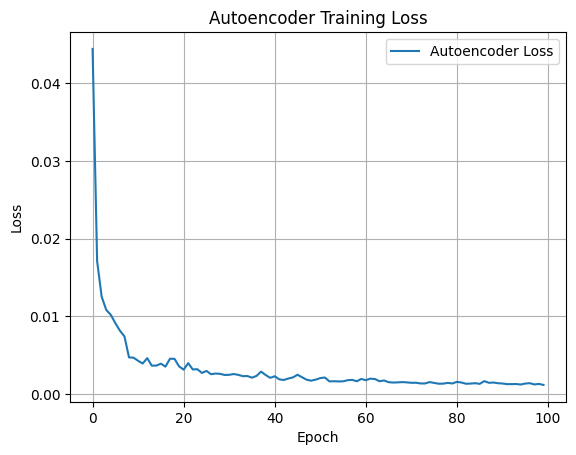

In [34]:
plt.plot(loss_list_autoencoder, label='Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()

# **Step 8.4:** Comparsion between an original image and its reconstruction by the Autoencoder

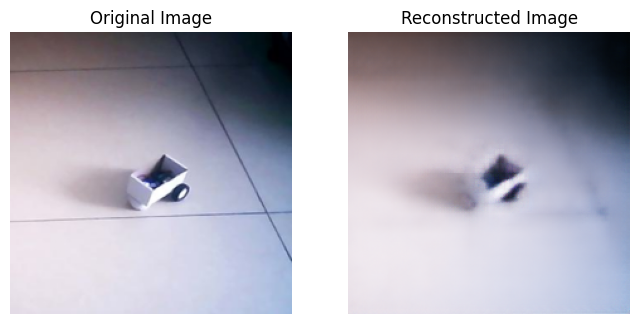

In [35]:
net_autoencoder.eval()

sample_input, _ = next(iter(train_loader))
sample_input = sample_input.to(device)

with torch.no_grad():
    reconstructed = net_autoencoder(sample_input)

original = sample_input.cpu().detach()
reconstructed = reconstructed.cpu().detach()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original[0].permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(reconstructed[0].permute(1, 2, 0))
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

plt.show()

# **Step 9:** Converting from a tensor representation to a vector representation

In [36]:
net_autoencoder.autoencoder = False

for param in net_autoencoder.decoder.parameters():
    param.requires_grad = False

# **Step 10 (Regression - labeled):** Splitting into Train\Test and Preparing the DataLoader

In [37]:
# User-provided list of images and angles
# We chose carefully 50 specific images to ensure a balanced distribution of angles across
# the entire 360-degree range.
# Each image in this list represents approximately a 7.2-degree interval
user_provided_data = [
    "agent_0454.jpg: 0.00 degrees", "agent_059.jpg: 7.54 degrees", "agent_061.jpg: 14.57 degrees",
    "agent_014.jpg: 22.29 degrees", "agent_0120.jpg: 29.41 degrees", "agent_0173.jpg: 37.35 degrees",
    "agent_0415.jpg: 43.32 degrees", "agent_0175.jpg: 50.44 degrees", "agent_0588.jpg: 57.95 degrees",
    "agent_0210.jpg: 65.22 degrees", "agent_0388.jpg: 72.35 degrees", "agent_0594.jpg: 80.64 degrees",
    "agent_0380.jpg: 86.50 degrees", "agent_0294.jpg: 95.44 degrees", "agent_0198.jpg: 101.61 degrees",
    "agent_0500.jpg: 108.16 degrees", "agent_0473.jpg: 115.56 degrees", "agent_0557.jpg: 124.45 degrees",
    "agent_0222.jpg: 130.24 degrees", "agent_0602.jpg: 137.00 degrees", "agent_0154.jpg: 145.01 degrees",
    "agent_036.jpg: 152.13 degrees", "agent_0224.jpg: 159.02 degrees", "agent_077.jpg: 169.32 degrees",
    "agent_0287.jpg: 173.57 degrees", "agent_0373.jpg: 180.63 degrees", "agent_0435.jpg: 188.24 degrees",
    "agent_0364.jpg: 195.07 degrees", "agent_0329.jpg: 202.43 degrees", "agent_0166.jpg: 208.81 degrees",
    "agent_074.jpg: 217.06 degrees", "agent_0434.jpg: 223.64 degrees", "agent_0396.jpg: 230.57 degrees",
    "agent_0317.jpg: 237.85 degrees", "agent_0567.jpg: 245.06 degrees", "agent_0433.jpg: 252.15 degrees",
    "agent_0483.jpg: 259.38 degrees", "agent_0163.jpg: 266.50 degrees", "agent_0183.jpg: 274.65 degrees",
    "agent_066.jpg: 281.16 degrees", "agent_010.jpg: 288.22 degrees", "agent_0336.jpg: 296.10 degrees",
    "agent_0411.jpg: 302.91 degrees", "agent_0426.jpg: 310.24 degrees", "agent_0538.jpg: 317.45 degrees",
    "agent_0332.jpg: 324.58 degrees", "agent_0476.jpg: 332.10 degrees", "agent_0449.jpg: 338.44 degrees",
    "agent_0177.jpg: 346.24 degrees", "agent_0107.jpg: 353.48 degrees"
]

selected_files_50 = []
selected_angles_50 = []

for entry in user_provided_data:
    parts = entry.split(': ')
    filename = parts[0]
    angle_str = parts[1].replace(' degrees', '')
    angle = np.float64(float(angle_str))

    selected_files_50.append(filename)
    selected_angles_50.append(angle)

print(f"Stored {len(selected_files_50)} filenames and angles.")
print("First 5 filenames:", selected_files_50[:5])
print("First 5 angles:", [f'{a:.2f}°' for a in selected_angles_50[:5]])

Stored 50 filenames and angles.
First 5 filenames: ['agent_0454.jpg', 'agent_059.jpg', 'agent_061.jpg', 'agent_014.jpg', 'agent_0120.jpg']
First 5 angles: ['0.00°', '7.54°', '14.57°', '22.29°', '29.41°']


In [38]:
# Split the image filenames and annotations into training and testing sets (80% train, 20% test)
train_files_full_split, test_files, train_annots_full_split, test_annots = train_test_split(
    image_files, annotations, test_size=0.2, random_state=42
)
# random_state sets a fixed seed for random number generation, ensuring that the data split is the same every time you run the code
# Without random_state the split will change every time — making it impossible to reproduce or consistently compare results

# --- Reconstruct train_annots for the 50 selected balanced images with full (x, y, angle) ---
# 1. Create a mapping from filename to its index in the original image_files
file_to_idx = {filename: i for i, filename in enumerate(image_files)}

# 2. Initialize a list to hold the full (x, y, angle) annotations for the selected files
new_train_annots_list = []

# 3. Iterate through selected_files_50 and retrieve the full annotation vector from the global 'annotations' array
for filename in selected_files_50:
    original_idx = file_to_idx[filename]
    # 'annotations' is already normalized [x, y, angle]
    new_train_annots_list.append(annotations[original_idx])

# 4. Convert the list to a NumPy array
train_annots = np.array(new_train_annots_list)
train_files = selected_files_50

# Create datasets for regression
train_dataset = CustomImageDataset(data_path, train_files, train_annots, transform=transform)
test_dataset = CustomImageDataset(data_path, test_files, test_annots, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# **Step 11.1:** Training preparations with new Loss Function

In [39]:
def custom_pose_loss(pred, target):
    # Split into (x, y) and angle
    pred_xy = pred[:, :2]
    target_xy = target[:, :2]
    pred_angle = pred[:, 2]
    target_angle = target[:, 2]

    # MSE for (x, y)
    xy_loss = F.mse_loss(pred_xy, target_xy)

    # Use 2π to account for full circle (normalized angles from 0 to 1)
    angle_diff = torch.atan2(
        torch.sin(2 * np.pi * (pred_angle - target_angle)),
        torch.cos(2 * np.pi * (pred_angle - target_angle))
    )
    angle_loss = torch.mean(angle_diff ** 2)

    # Combine the two losses
    total_loss = xy_loss + angle_loss
    return total_loss, xy_loss.item(), angle_loss.item() # Return individual losses too

optimizer = optim.Adam(net_autoencoder.parameters(), lr=5e-6)

num_epochs = 10
loss_list = []
xy_loss_list = [] # New list to store XY losses per epoch
angle_loss_list = [] # New list to store Angle losses per epoch

# **Step 11.2:** Training with new Loss Function

In [40]:
num_epochs=300

test_xy_rmse_list = [] # Initialize new list to store test XY RMSE
test_angle_rmse_list = [] # Initialize new list to store test Angle RMSE

for epoch in range(num_epochs):
    net_autoencoder.train()
    running_loss = 0.0
    running_xy_loss = 0.0 # New running total for XY loss
    running_angle_loss = 0.0 # New running total for Angle loss

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net_autoencoder(inputs)
        total_loss, xy_l, angle_l = custom_pose_loss(outputs, labels) # Get individual losses
        total_loss.backward()
        optimizer.step() # Update the model's weights using the calculated gradients

        running_loss += total_loss.item() * inputs.size(0)
        running_xy_loss += xy_l * inputs.size(0) # Accumulate XY loss
        running_angle_loss += angle_l * inputs.size(0) # Accumulate Angle loss

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_xy_loss = running_xy_loss / len(train_loader.dataset) # Calculate average XY loss for the epoch in MSE (normalized)
    epoch_angle_loss = running_angle_loss / len(train_loader.dataset) # Calculate average Angle loss for the epoch in MSE (rad^2)

    epoch_xy_pixels = np.sqrt(epoch_xy_loss) * 224 # Convert MSE (normalized) to RMSE (pixels) - image size = 224
    epoch_angle_degrees = np.sqrt(epoch_angle_loss) * (180 / np.pi) # Convert MSE (rad^2) to RMSE (degrees)

    loss_list.append(epoch_loss)
    xy_loss_list.append(epoch_xy_pixels) # Store average XY loss
    angle_loss_list.append(epoch_angle_degrees) # Store average Angle loss

    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {epoch_loss:.4f}, XY Loss: {epoch_xy_pixels:.4f}, Angle Loss: {epoch_angle_degrees:.4f}") # Updated print

    # --- Evaluation on test set ---
    net_autoencoder.eval()
    test_total_mse_xy = 0.0
    test_total_mse_angle = 0.0
    test_total_samples = 0
    img_size = 224 # Assuming image size is 224x224 as set in transform

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_autoencoder(inputs)

            pred_xy = outputs[:, :2]
            true_xy = labels[:, :2]
            pred_angle = outputs[:, 2]
            true_angle = labels[:, 2]

            # Calculate MSE for (x, y)
            mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')
            test_total_mse_xy += mse_xy.item()

            # Calculate angle difference using atan2 for cyclic loss
            angle_diff = torch.atan2(
                torch.sin(2 * np.pi * (pred_angle - true_angle)),
                torch.cos(2 * np.pi * (pred_angle - true_angle))
            )
            mse_angle = torch.sum(angle_diff ** 2)
            test_total_mse_angle += mse_angle.item()

            test_total_samples += inputs.size(0)

    # Calculate average test RMSE
    avg_test_mse_xy = test_total_mse_xy / test_total_samples
    avg_test_mse_angle = test_total_mse_angle / test_total_samples

    test_rmse_xy_pixels = (avg_test_mse_xy ** 0.5) * img_size
    test_rmse_angle_degrees = (avg_test_mse_angle ** 0.5) * (180.0 / np.pi)

    test_xy_rmse_list.append(test_rmse_xy_pixels)
    test_angle_rmse_list.append(test_rmse_angle_degrees)

    # print(f"Test Set RMSE after Epoch {epoch+1}: XY: {test_rmse_xy_pixels:.2f} pixels, Angle: {test_rmse_angle_degrees:.2f} degrees\n")

    net_autoencoder.train()

print("Regression mode training finished")

Epoch [1/300], Total Loss: 3.3685, XY Loss: 29.7587, Angle Loss: 104.8824
Epoch [2/300], Total Loss: 2.5011, XY Loss: 27.6275, Angle Loss: 90.3366
Epoch [3/300], Total Loss: 2.2035, XY Loss: 26.1897, Angle Loss: 84.7873
Epoch [4/300], Total Loss: 1.9457, XY Loss: 24.7681, Angle Loss: 79.6704
Epoch [5/300], Total Loss: 1.8863, XY Loss: 23.9848, Angle Loss: 78.4512
Epoch [6/300], Total Loss: 1.7440, XY Loss: 23.2943, Angle Loss: 75.4301
Epoch [7/300], Total Loss: 1.5672, XY Loss: 22.4001, Angle Loss: 71.4983
Epoch [8/300], Total Loss: 1.4459, XY Loss: 22.0421, Angle Loss: 68.6652
Epoch [9/300], Total Loss: 1.3027, XY Loss: 21.5770, Angle Loss: 65.1619
Epoch [10/300], Total Loss: 1.1943, XY Loss: 21.3291, Angle Loss: 62.3765
Epoch [11/300], Total Loss: 1.1905, XY Loss: 20.6810, Angle Loss: 62.2905
Epoch [12/300], Total Loss: 1.0873, XY Loss: 20.5543, Angle Loss: 59.5126
Epoch [13/300], Total Loss: 1.0615, XY Loss: 20.3849, Angle Loss: 58.8005
Epoch [14/300], Total Loss: 0.9910, XY Loss: 1

In [41]:
# Save model weights after training
torch.save(net_autoencoder.state_dict(), '/content/drive/MyDrive/my_regression_model_weights.pth')
print("Model weights saved to Google Drive.")

Model weights saved to Google Drive.


# **Step 11.3:** Graph for Regression

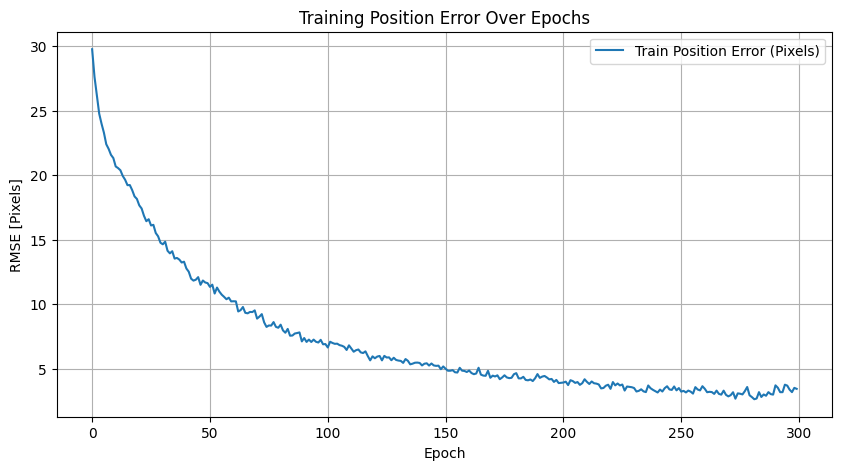

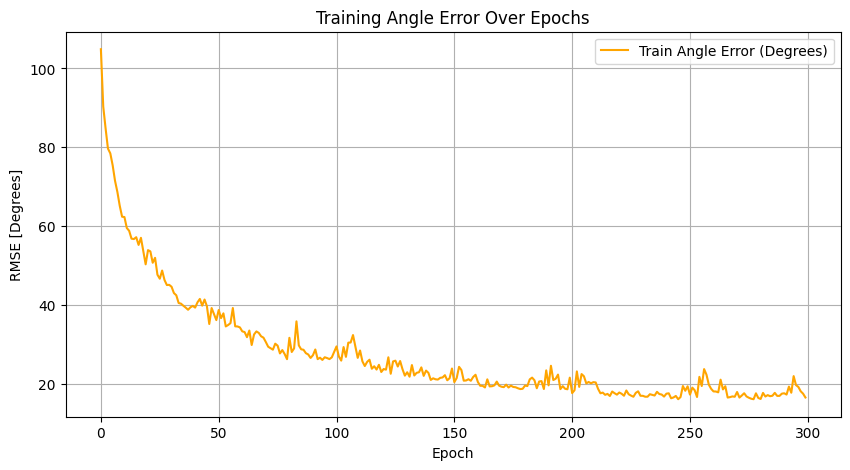

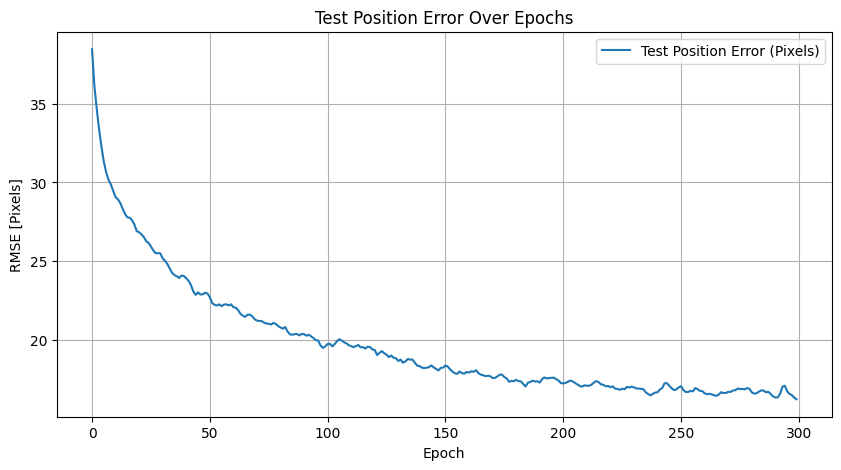

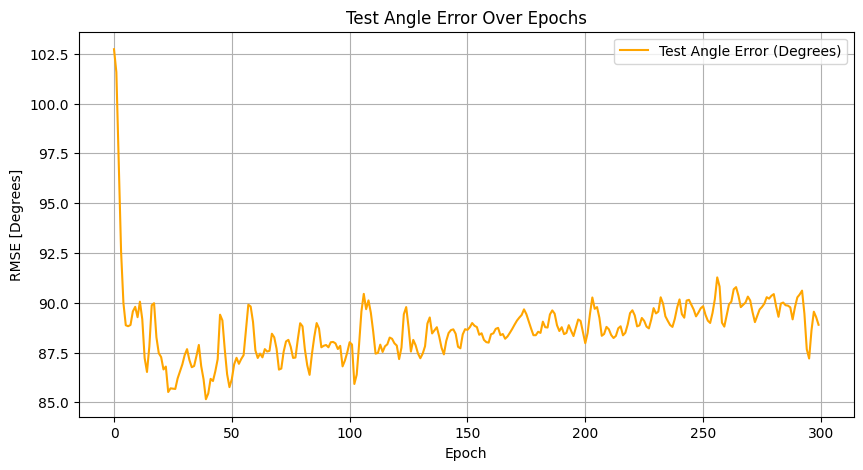

In [42]:
# --- Plot for XY Position Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(xy_loss_list, label='Train Position Error (Pixels)') # Update label
plt.xlabel('Epoch')
plt.ylabel('RMSE [Pixels]') # Clear unit on Y axis
plt.title('Training Position Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(angle_loss_list, label='Train Angle Error (Degrees)', color='orange') # Update label
plt.xlabel('Epoch')
plt.ylabel('RMSE [Degrees]') # Clear unit on Y axis
plt.title('Training Angle Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for XY Position Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_xy_rmse_list, label='Test Position Error (Pixels)')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Pixels]')
plt.title('Test Position Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_angle_rmse_list, label='Test Angle Error (Degrees)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Degrees]')
plt.title('Test Angle Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **Step 11.4:** Test the network on the data

Ground truth (x, y, angle):
[[0.5        0.45555556 0.70497495]
 [0.5        0.12777779 0.7984644 ]
 [0.5        0.5        0.6875571 ]
 [0.5        0.3638889  0.4826277 ]
 [0.5        0.2888889  0.7828947 ]
 [0.3611111  0.5        0.6718785 ]
 [0.5        0.5        0.824832  ]
 [0.5        0.14722222 0.6526127 ]
 [0.5        0.36944443 0.29012233]
 [0.3        0.45277777 0.27380317]
 [0.5        0.5        0.3620365 ]
 [0.5        0.49722221 0.06881984]
 [0.5        0.44722223 0.812341  ]
 [0.5        0.48333332 0.22709355]
 [0.5        0.5        0.9297841 ]
 [0.5        0.5        0.69316036]]
Predicted (x, y, angle):
[[0.48891136 0.42632094 0.9793444 ]
 [0.504832   0.30001497 0.69122386]
 [0.49304345 0.50426656 0.72633064]
 [0.49883354 0.36724055 0.86592335]
 [0.4592236  0.31379876 0.69865483]
 [0.38686365 0.510547   0.5030654 ]
 [0.5150755  0.4636563  0.6635359 ]
 [0.4760436  0.37578368 0.23612793]
 [0.48690593 0.33495373 0.9011717 ]
 [0.4208683  0.42418012 0.76517296]
 [0.489426

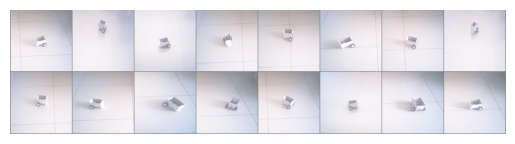

In [43]:
def imshow(img): # Define a function to display a batch of images
    img = img * 0.5 + 0.5  # Reverse the normalization to convert the image back to [0, 1] range for visualization
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(test_loader) # Provides one item at a time when using next()
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Run predictions
net_autoencoder.eval()
with torch.no_grad():
    outputs = net_autoencoder(images)

print("Ground truth (x, y, angle):")
print(labels.cpu().numpy())
print("Predicted (x, y, angle):")
print(outputs.cpu().numpy())

imshow(torchvision.utils.make_grid(images.cpu()))


# **Step 11.5:** Calculate the square Loss

In [44]:
def evaluate_model(model, test_loader, device, img_size=224):
  net_autoencoder.eval()
  total_samples = 0
  total_mse_xy = 0.0
  total_mse_angle = 0.0

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = net_autoencoder(inputs)

          pred_xy = outputs[:, :2]
          true_xy = labels[:, :2]
          pred_angle = outputs[:, 2]
          true_angle = labels[:, 2]

          # Calculate MSE for (x, y) as a single value
          mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')  # sum over all samples
          total_mse_xy += mse_xy.item()

          # Calculate angle difference using atan2
          angle_diff = torch.atan2(
              torch.sin(2 * np.pi * (pred_angle - true_angle)),
              torch.cos(2 * np.pi * (pred_angle - true_angle))
          )
          mse_angle = torch.sum(angle_diff ** 2)  # sum over all samples
          total_mse_angle += mse_angle.item()

          total_samples += inputs.size(0)

  # Average losses
  avg_mse_xy = total_mse_xy / total_samples # Normalized units
  avg_mse_angle = total_mse_angle / total_samples # radians^2

  # Root mean square errors
  rmse_xy_norm = avg_mse_xy ** 0.5 # Normalized
  rmse_xy_pixels = rmse_xy_norm * img_size

  rmse_angle_rad = (avg_mse_angle ** 0.5)
  rmse_angle_deg = rmse_angle_rad * (180.0 / np.pi)

  print(f"Average MSE for Position (X & Y) on test data: {avg_mse_xy:.4f}")
  print(f"RMSE Position: {rmse_xy_norm:.4f} (normalized), {rmse_xy_pixels:.2f} pixels")

  print(f"Average MSE for Angle on test data: {avg_mse_angle:.4f}")
  print(f"RMSE Angle on test data: {rmse_angle_deg:.2f} degrees")
  print(f"RMSE Angle on train data: {epoch_angle_degrees:.2f} degrees")
  print(f"RMSE Position on train data: {epoch_xy_pixels:.2f} pixels")




In [45]:
net_autoencoder.autoencoder = False # Making sure we are on Regression mode
evaluate_model(net_autoencoder, test_loader, device)


Average MSE for Position (X & Y) on test data: 0.0053
RMSE Position: 0.0725 (normalized), 16.25 pixels
Average MSE for Angle on test data: 2.4071
RMSE Angle on test data: 88.89 degrees
RMSE Angle on train data: 16.50 degrees
RMSE Position on train data: 3.46 pixels


# **Step 11.6:** Display 5 Test Images with Original + Predicted Arrows

In [46]:
def plot_image_with_arrows(image, predicted_pose, true_pose):
    # Convert image tensor to NumPy and clip values for display
    img_np = image.cpu().numpy().transpose((1, 2, 0))
    img_np = np.clip(img_np, 0, 1)
    h, w = img_np.shape[:2]

    # === Denormalize predicted pose ===
    pred_x = predicted_pose[0] * w      # from [0,1] * image width
    pred_y = predicted_pose[1] * h      # from [0,1] * image height
    pred_angle_deg = predicted_pose[2] * 360
    pred_angle_deg = -pred_angle_deg + 90
    pred_angle_rad = np.deg2rad(pred_angle_deg)

    # === Denormalize true pose ===
    true_x = true_pose[0] * w
    true_y = true_pose[1] * h
    true_angle_deg = true_pose[2] * 360
    true_angle_deg = -true_angle_deg + 90
    true_angle_rad = np.deg2rad(true_angle_deg)

    arrow_len = 40

    # Plot image
    plt.imshow(img_np)

    # Predicted arrow (RED)
    plt.arrow(pred_x, pred_y,
              arrow_len * np.cos(pred_angle_rad),
              -arrow_len * np.sin(pred_angle_rad),
              head_width=6, head_length=8, fc='red', ec='red')

    # Ground truth arrow (BLUE)
    plt.arrow(true_x, true_y,
              arrow_len * np.cos(true_angle_rad),
              -arrow_len * np.sin(true_angle_rad),
              head_width=6, head_length=8, fc='blue', ec='blue')

    print(f"Predicted X norm: {predicted_pose[0]}, denorm: {pred_x}")
    print(f"True X norm: {true_pose[0]}, denorm: {true_x}")


    # Display title and remove axes
    plt.title(f"Pred: ({pred_x:.1f}, {pred_y:.1f}, {pred_angle_deg:.1f}°) | "
              f"True: ({true_x:.1f}, {true_y:.1f}, {true_angle_deg:.1f}°)")
    plt.axis('off')
    plt.show()


# Function to visualize predictions of 5 images
def visualize_predictions(net_autoencoder, test_loader, device, num_images=5):
    net_autoencoder.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net_autoencoder(images)

            for i in range(images.size(0)):
                if shown >= num_images:
                    return

                predicted = outputs[i].cpu().numpy()
                true = labels[i].cpu().numpy()

                print(f"\nImage {shown + 1}:")
                print("  Ground Truth (x, y, angle):", true * np.array([max_x, max_y, max_angle]))
                print("  Predicted     (x, y, angle):", predicted * np.array([max_x, max_y, max_angle]))

                plot_image_with_arrows(images[i], predicted, true)
                shown += 1



Image 1:
  Ground Truth (x, y, angle): [180.         164.00000095 253.79098177]
  Predicted     (x, y, angle): [176.00808978 153.47553849 352.56399393]
Predicted X norm: 0.48891136050224304, denorm: 109.51614379882812
True X norm: 0.5, denorm: 112.0


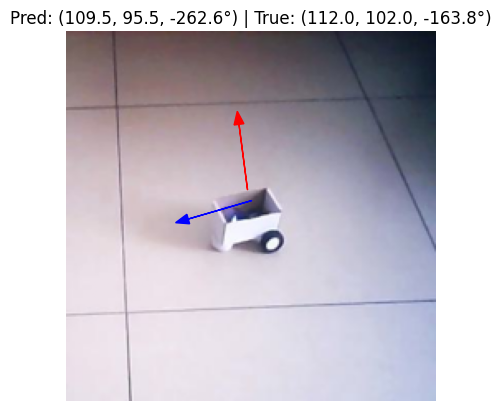


Image 2:
  Ground Truth (x, y, angle): [180.          46.00000262 287.44719028]
  Predicted     (x, y, angle): [181.73953056 108.00539017 248.84058952]
Predicted X norm: 0.5048320293426514, denorm: 113.0823745727539
True X norm: 0.5, denorm: 112.0


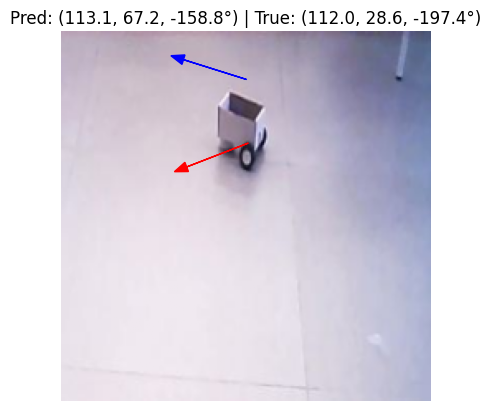


Image 3:
  Ground Truth (x, y, angle): [180.         180.         247.52055645]
  Predicted     (x, y, angle): [177.4956429  181.53596163 261.47902966]
Predicted X norm: 0.493043452501297, denorm: 110.44173431396484
True X norm: 0.5, denorm: 112.0


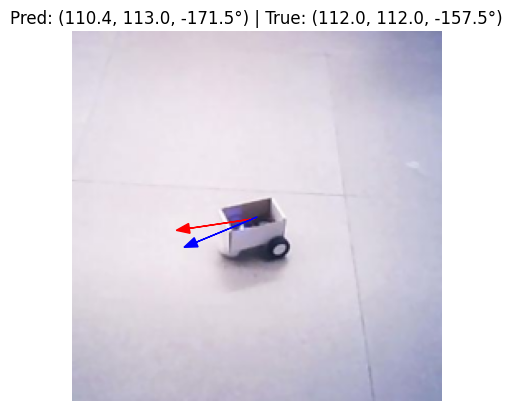


Image 4:
  Ground Truth (x, y, angle): [180.         131.00000024 173.74596834]
  Predicted     (x, y, angle): [179.58007336 132.20659733 311.73240423]
Predicted X norm: 0.4988335371017456, denorm: 111.73870849609375
True X norm: 0.5, denorm: 112.0


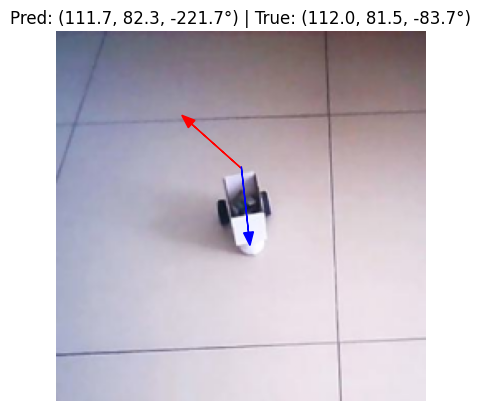


Image 5:
  Ground Truth (x, y, angle): [180.         104.00000453 281.84208155]
  Predicted     (x, y, angle): [165.32049537 112.96755195 251.51573896]
Predicted X norm: 0.45922359824180603, denorm: 102.8660888671875
True X norm: 0.5, denorm: 112.0


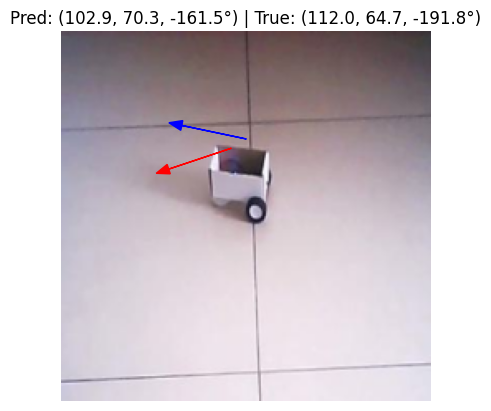

In [47]:
visualize_predictions(net_autoencoder, test_loader, device)

# **Step 11.7:** Show Accuracy for (X,Y) and Angle Predictions on Test Set

In [48]:
def evaluate_pose_accuracy(net_autoencoder, test_loader, device):
    net_autoencoder.eval()

    total_samples = 0
    total_x_error = 0.0
    total_y_error = 0.0
    total_angle_error = 0.0 # in degrees

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net_autoencoder(images)

            # Unnormalize both predictions and labels
            preds = outputs.cpu().numpy() * np.array([max_x, max_y, max_angle])
            trues = labels.cpu().numpy() * np.array([max_x, max_y, max_angle])

            # Compute absolute position errors
            total_x_error += np.abs(preds[:, 0] - trues[:, 0]).sum()
            total_y_error += np.abs(preds[:, 1] - trues[:, 1]).sum()

            # Compute angular error (wrapped to [-180, 180] range)
            delta_deg = preds[:, 2] - trues[:, 2]
            angle_err_rad = np.arctan2(
                np.sin(np.deg2rad(delta_deg)),
                np.cos(np.deg2rad(delta_deg))
            )
            angle_err_deg = np.abs(np.rad2deg(angle_err_rad))  # convert to degrees and take abs
            total_angle_error += angle_err_deg.sum()

            total_samples += preds.shape[0]

    # Mean Absolute Errors (MAE)
    mean_x_error = total_x_error / total_samples
    mean_y_error = total_y_error / total_samples
    mean_angle_error = total_angle_error / total_samples

    print("Prediction Accuracy on Test Set:")
    print(f"  Mean Absolute Error in X:     {mean_x_error:.2f} pixels")
    print(f"  Mean Absolute Error in Y:     {mean_y_error:.2f} pixels")
    print(f"  Mean Absolute Error in Angle: {mean_angle_error:.2f} degrees")

evaluate_pose_accuracy(net_autoencoder, test_loader, device)

Prediction Accuracy on Test Set:
  Mean Absolute Error in X:     10.61 pixels
  Mean Absolute Error in Y:     12.77 pixels
  Mean Absolute Error in Angle: 69.60 degrees
